In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import os

from models import FluxNet, ResMLP
from models import compute_divergence_field

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load training data

In [2]:
train_data = torch.load("data/train_flux_tensor.pt", weights_only = False)
test_data = torch.load("data/test_flux_tensor.pt", weights_only = False)
# 2.2 M data points
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

### Make torch.dataset ###
# takes two separate tensors as input
train_dataset = TensorDataset(train_data[:, :2], train_data[:, 2:])
test_dataset = TensorDataset(test_data[:, :2], test_data[:, 2:])

### Create DataLoader ###
train_loader = DataLoader(train_dataset, batch_size = 1024, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 1024, shuffle = False)

Train data shape: torch.Size([2250146, 4])
Test data shape: torch.Size([957943, 4])


## Train & Save Fluxnet

In [13]:
RETRAIN = True

# define eval loop
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    loss_sum = 0.0
    for Xb, Yb in loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)
        Yhat = model(Xb)
        loss = loss_fn(Yhat, Yb)
        loss_sum += loss.item() * Xb.size(0)
    return loss_sum / len(loader.dataset)

if RETRAIN:
    fluxnet_model = FluxNet().to(device)
    optim = torch.optim.AdamW(fluxnet_model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 12
    train_losses, test_losses = [], []

    for ep in range(1, epochs + 1):
        
        # ------------------ TRAIN ------------------
        fluxnet_model.train()
        train_loss_sum = 0.0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none=True)

            Y_hat = fluxnet_model(X_batch)
            loss = loss_function(Y_hat, Y_batch)

            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_train = train_loss_sum / len(train_loader.dataset)
        train_losses.append(epoch_train)

        # ------------------ TEST / VAL ------------------
        # assumes you have test_loader defined
        epoch_test = eval_epoch(fluxnet_model, test_loader, loss_function, device)
        test_losses.append(epoch_test)

        print(f"[epoch {ep:03d}] train_loss = {epoch_train:.6f} | test_loss = {epoch_test:.6f}")

    # ------------------ SAVE ------------------
    torch.save(fluxnet_model.state_dict(), "trained_models/fluxnet_trained.pth")
    pd.DataFrame({"train_loss": train_losses, "test_loss": test_losses}).to_csv(
        "trained_models/fluxnet_trained_loss.csv", index = False
    )

[epoch 001] train_loss = 0.131798 | test_loss = 0.035748
[epoch 002] train_loss = 0.023934 | test_loss = 0.019598
[epoch 003] train_loss = 0.017818 | test_loss = 0.014786
[epoch 004] train_loss = 0.016790 | test_loss = 0.016600
[epoch 005] train_loss = 0.014963 | test_loss = 0.015729
[epoch 006] train_loss = 0.012279 | test_loss = 0.011644
[epoch 007] train_loss = 0.012050 | test_loss = 0.012173
[epoch 008] train_loss = 0.011326 | test_loss = 0.010009
[epoch 009] train_loss = 0.010642 | test_loss = 0.011535
[epoch 010] train_loss = 0.009901 | test_loss = 0.009764
[epoch 011] train_loss = 0.009956 | test_loss = 0.011077
[epoch 012] train_loss = 0.009322 | test_loss = 0.012471


### run for 25 eps to see

In [7]:
RETRAIN = True

# define eval loop
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    loss_sum = 0.0
    for Xb, Yb in loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)
        Yhat = model(Xb)
        loss = loss_fn(Yhat, Yb)
        loss_sum += loss.item() * Xb.size(0)
    return loss_sum / len(loader.dataset)

if RETRAIN:
    fluxnet_model = FluxNet().to(device)
    optim = torch.optim.AdamW(fluxnet_model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 25
    train_losses, test_losses = [], []

    for ep in range(1, epochs + 1):
        
        # ------------------ TRAIN ------------------
        fluxnet_model.train()
        train_loss_sum = 0.0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none=True)

            Y_hat = fluxnet_model(X_batch)
            loss = loss_function(Y_hat, Y_batch)

            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_train = train_loss_sum / len(train_loader.dataset)
        train_losses.append(epoch_train)

        # ------------------ TEST / VAL ------------------
        # assumes you have test_loader defined
        epoch_test = eval_epoch(fluxnet_model, test_loader, loss_function, device)
        test_losses.append(epoch_test)

        print(f"[epoch {ep:03d}] train_loss = {epoch_train:.6f} | test_loss = {epoch_test:.6f}")

    # ------------------ SAVE ------------------
    torch.save(fluxnet_model.state_dict(), "trained_models/fluxnet_trained_ep25.pth")
    pd.DataFrame({"train_loss": train_losses, "test_loss": test_losses}).to_csv(
        "trained_models/fluxnet_trained_loss_ep25.csv", index = False
    )

[epoch 001] train_loss = 0.103989 | test_loss = 0.030109
[epoch 002] train_loss = 0.021872 | test_loss = 0.026818
[epoch 003] train_loss = 0.017724 | test_loss = 0.018028
[epoch 004] train_loss = 0.016277 | test_loss = 0.012496
[epoch 005] train_loss = 0.016842 | test_loss = 0.014403
[epoch 006] train_loss = 0.013564 | test_loss = 0.013260
[epoch 007] train_loss = 0.012756 | test_loss = 0.010559
[epoch 008] train_loss = 0.011791 | test_loss = 0.011077
[epoch 009] train_loss = 0.011015 | test_loss = 0.011172
[epoch 010] train_loss = 0.010468 | test_loss = 0.011795
[epoch 011] train_loss = 0.010501 | test_loss = 0.012091
[epoch 012] train_loss = 0.009409 | test_loss = 0.012520
[epoch 013] train_loss = 0.009319 | test_loss = 0.011321
[epoch 014] train_loss = 0.009169 | test_loss = 0.009515
[epoch 015] train_loss = 0.008938 | test_loss = 0.010098
[epoch 016] train_loss = 0.008770 | test_loss = 0.010183
[epoch 017] train_loss = 0.008446 | test_loss = 0.009411
[epoch 018] train_loss = 0.0083

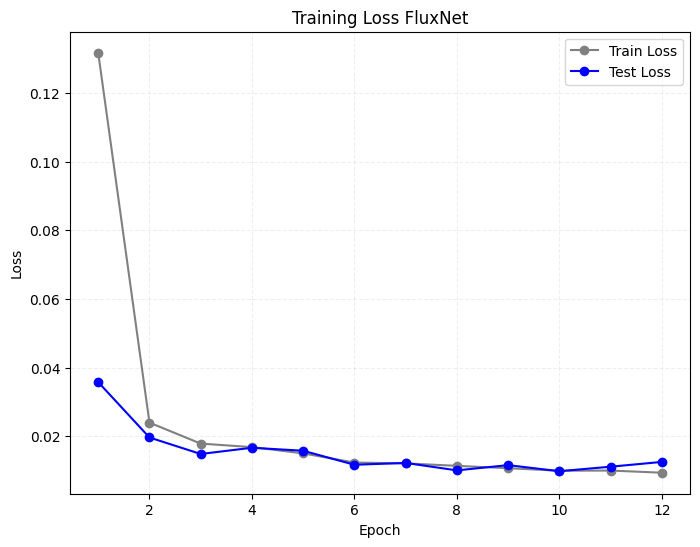

In [14]:
if RETRAIN:
    # Assume you already have train_losses and test_losses lists
    epochs = range(1, len(losses) + 1)

    plt.figure(figsize = (8, 6))
    plt.plot(epochs, train_losses, label = "Train Loss", marker = "o", color = "gray")
    plt.plot(epochs, test_losses, label = "Test Loss", marker = "o", color = "blue")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss FluxNet")
    plt.legend()

    plt.grid(True, linestyle = "--", alpha = 0.2)
    # plt.ylim(0, 0.5)
    plt.show()

## Train & save an NN

In [3]:
RETRAIN = True

# define eval loop
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    loss_sum = 0.0
    for Xb, Yb in loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)
        Yhat = model(Xb)
        loss = loss_fn(Yhat, Yb)
        loss_sum += loss.item() * Xb.size(0)
    return loss_sum / len(loader.dataset)

if RETRAIN:
    resmlp_model = ResMLP().to(device)
    optim = torch.optim.AdamW(resmlp_model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 12
    train_losses, test_losses = [], []

    for ep in range(1, epochs + 1):
        
        # ------------------ TRAIN ------------------
        resmlp_model.train()
        train_loss_sum = 0.0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none=True)

            Y_hat = resmlp_model(X_batch)
            loss = loss_function(Y_hat, Y_batch)

            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_train = train_loss_sum / len(train_loader.dataset)
        train_losses.append(epoch_train)

        # ------------------ TEST / VAL ------------------
        # assumes you have test_loader defined
        epoch_test = eval_epoch(resmlp_model, test_loader, loss_function, device)
        test_losses.append(epoch_test)

        print(f"[epoch {ep:03d}] train_loss = {epoch_train:.6f} | test_loss = {epoch_test:.6f}")

    # ------------------ SAVE ------------------
    torch.save(resmlp_model.state_dict(), "trained_models/resmlp_trained.pth")
    pd.DataFrame({"train_loss": train_losses, "test_loss": test_losses}).to_csv(
        "trained_models/resmlp_trained_loss.csv", index = False
    )

[epoch 001] train_loss = 0.127174 | test_loss = 0.028745
[epoch 002] train_loss = 0.021144 | test_loss = 0.015008
[epoch 003] train_loss = 0.016456 | test_loss = 0.014259
[epoch 004] train_loss = 0.014827 | test_loss = 0.014209
[epoch 005] train_loss = 0.013045 | test_loss = 0.017209
[epoch 006] train_loss = 0.011938 | test_loss = 0.014246
[epoch 007] train_loss = 0.011465 | test_loss = 0.011698
[epoch 008] train_loss = 0.010751 | test_loss = 0.015646
[epoch 009] train_loss = 0.010226 | test_loss = 0.012961
[epoch 010] train_loss = 0.010109 | test_loss = 0.011914
[epoch 011] train_loss = 0.009313 | test_loss = 0.011592
[epoch 012] train_loss = 0.011874 | test_loss = 0.017322


In [6]:
RETRAIN = True

# define eval loop
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    loss_sum = 0.0
    for Xb, Yb in loader:
        Xb = Xb.to(device)
        Yb = Yb.to(device)
        Yhat = model(Xb)
        loss = loss_fn(Yhat, Yb)
        loss_sum += loss.item() * Xb.size(0)
    return loss_sum / len(loader.dataset)

if RETRAIN:
    resmlp_model = ResMLP().to(device)
    optim = torch.optim.AdamW(resmlp_model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 25
    train_losses, test_losses = [], []

    for ep in range(1, epochs + 1):
        
        # ------------------ TRAIN ------------------
        resmlp_model.train()
        train_loss_sum = 0.0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none=True)

            Y_hat = resmlp_model(X_batch)
            loss = loss_function(Y_hat, Y_batch)

            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_train = train_loss_sum / len(train_loader.dataset)
        train_losses.append(epoch_train)

        # ------------------ TEST / VAL ------------------
        # assumes you have test_loader defined
        epoch_test = eval_epoch(resmlp_model, test_loader, loss_function, device)
        test_losses.append(epoch_test)

        print(f"[epoch {ep:03d}] train_loss = {epoch_train:.6f} | test_loss = {epoch_test:.6f}")

    # ------------------ SAVE ------------------
    torch.save(resmlp_model.state_dict(), "trained_models/resmlp_trained_ep25.pth")
    pd.DataFrame({"train_loss": train_losses, "test_loss": test_losses}).to_csv(
        "trained_models/resmlp_trained_loss_ep25.csv", index = False
    )

[epoch 001] train_loss = 0.144221 | test_loss = 0.022015
[epoch 002] train_loss = 0.019658 | test_loss = 0.030720
[epoch 003] train_loss = 0.017330 | test_loss = 0.017185
[epoch 004] train_loss = 0.015280 | test_loss = 0.020006
[epoch 005] train_loss = 0.013172 | test_loss = 0.015820
[epoch 006] train_loss = 0.012701 | test_loss = 0.021019
[epoch 007] train_loss = 0.011872 | test_loss = 0.011918
[epoch 008] train_loss = 0.011094 | test_loss = 0.013037
[epoch 009] train_loss = 0.010206 | test_loss = 0.012240
[epoch 010] train_loss = 0.029538 | test_loss = 0.014086
[epoch 011] train_loss = 0.013223 | test_loss = 0.011234
[epoch 012] train_loss = 0.012227 | test_loss = 0.012010
[epoch 013] train_loss = 0.011825 | test_loss = 0.016937
[epoch 014] train_loss = 0.010827 | test_loss = 0.012670
[epoch 015] train_loss = 0.010103 | test_loss = 0.013931
[epoch 016] train_loss = 0.009716 | test_loss = 0.010060
[epoch 017] train_loss = 0.009214 | test_loss = 0.011457
[epoch 018] train_loss = 0.0086

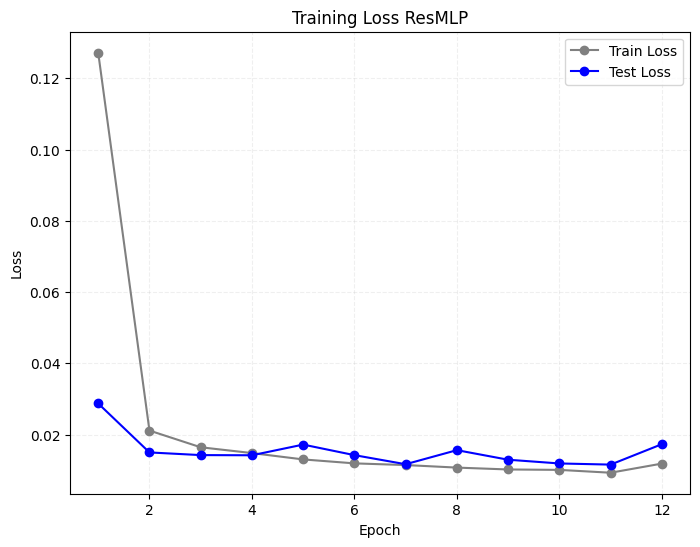

In [4]:
if RETRAIN:
    # Assume you already have train_losses and test_losses lists
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize = (8, 6))
    plt.plot(epochs, train_losses, label = "Train Loss", marker = "o", color = "gray")
    plt.plot(epochs, test_losses, label = "Test Loss", marker = "o", color = "blue")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss ResMLP")
    plt.legend()

    plt.grid(True, linestyle = "--", alpha = 0.2)
    # plt.ylim(0, 0.5)
    plt.show()

# FluxNet + dir

In [ ]:
# Directional guidance data

In [ ]:
RETRAIN = True
# ----- Training loop -----
if RETRAIN:
    fluxnet_model = FluxNet().to(device)
    # 5e-3 was a bit jittery
    optim = torch.optim.AdamW(fluxnet_model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 12

    losses = []

    for ep in range(1, epochs + 1):
        # ------------------ TRAIN ------------------
        fluxnet_model.train()
        train_loss_sum = 0.0
        
        # NOTE: Train on ALL data (no split)
        for i, (X_batch, Y_batch) in enumerate(all_loader):

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none = True)

            Y_hat = fluxnet_model(X_batch)

            loss = loss_function(Y_hat, Y_batch)
            
            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_avg_train_loss = train_loss_sum / len(all_loader.dataset)

        # store for plotting later
        losses.append(epoch_avg_train_loss)

        # Print every epoch: ~ 2 min per epoch
        # ~14 min for 10 epochs on GPU
        print(f"[epoch {ep:03d}] train_loss = {epoch_avg_train_loss:.6f}")

    # ------------------ SAVE ------------------
    torch.save(fluxnet_model.state_dict(), "trained_models/fluxnet_trained.pth")
    pd.DataFrame({'train_loss': losses}).to_csv("trained_models/fluxnet_trained_loss.csv", index = False)